# Lab 4: Data Quality Assessment & Preprocessing

## Data Quality Assessment and Preprocessing using the train Dataset


# Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Task 1
#### Data Quality Assessment

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [3]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [4]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
df.duplicated().sum()

0

The dataset is generally clean with no duplicate rows found. However, there are 11 missing values in the "Postal Code" column. Some columns such as "Order Date" and "Ship Date" are stored as object instead of datetime, which may require conversion. The "Sales" column shows a wide range between minimum and maximum values, suggesting possible outliers. Additionally, most of the columns are categorical, which may need encoding in later steps.

# Task 2
#### Handling Missing Values

In [6]:
postal_mode = df['Postal Code'].mode()[0]
df['Postal Code'] = df['Postal Code'].fillna(postal_mode)
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

Missing values in the "Postal Code" column were successfully handled using mode imputation. Since this feature behaves like a categorical variable, replacing missing values with the most frequent value is appropriate. After applying this step, the dataset no longer contains any missing values, making it clean and ready for further processing.

# Task3
#### Outlier Detection and Treatment (IQR)

In [7]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 17.248
Q3: 210.60500000000002
IQR: 193.35700000000003
Lower Bound: -272.7875000000001
Upper Bound: 500.6405000000001


In [8]:
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print("Number of outliers in Sales:", outliers.shape[0])
outliers.head()


Number of outliers in Sales: 1145


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
10,11,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840
11,12,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240


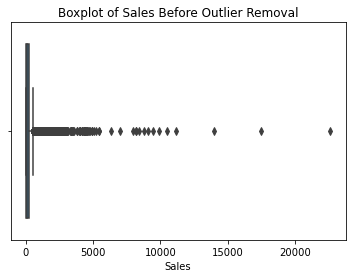

In [11]:
sns.boxplot(x=df['Sales'])
plt.title("Boxplot of Sales Before Outlier Removal")
plt.show()

In [12]:
df = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]


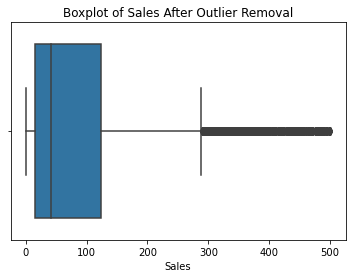

In [13]:
sns.boxplot(x=df['Sales'])
plt.title("Boxplot of Sales After Outlier Removal")
plt.show()

Outliers in the "Sales" column were detected using the IQR method. Values outside the lower and upper bounds were removed to reduce their impact. After removal, the data became more consistent and suitable for analysis.

# Task4
#### Data Normalization (Min-Max and Z-score)

##### Select numerical features

In [14]:
numerical_features = ['Sales', 'Postal Code', 'Row ID']

##### Min-Max Normalization

In [15]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[numerical_features] = minmax_scaler.fit_transform(df[numerical_features])

df_minmax[numerical_features].head()

,Sales,Postal Code,Row ID
0,0.523245,0.421123,0.000000
2,0.028364,0.905710,0.000204
4,0.043866,0.328421,0.000408
5,0.096872,0.905670,0.000510
6,0.013678,0.905670,0.000612


##### Z-score Standardization

In [16]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[numerical_features] = zscore_scaler.fit_transform(df[numerical_features])

df_zscore[numerical_features].head()

,Sales,Postal Code,Row ID
0,1.471371,-0.405875,-1.736380
2,-0.685287,1.083545,-1.735674
4,-0.617729,-0.690802,-1.734967
5,-0.386735,1.083420,-1.734614
6,-0.749288,1.083420,-1.734261


Two normalization techniques were applied to the numerical features ("Sales", "Postal Code", and "Row ID"). Min-Max normalization scaled the values between 0 and 1, while Z-score standardization transformed the data to have a mean of 0 and a standard deviation of 1. These techniques improve data consistency and prepare the data for machine learning models.

# Task5 
#### Principal Component Analysis (PCA)

In [27]:
from sklearn.preprocessing import LabelEncoder

for col in ['Segment', 'Region', 'Category']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [28]:
df[['Sales', 'Segment', 'Region', 'Category']].dtypes

Sales       float64
Segment       int64
Region        int64
Category      int64
dtype: object

In [29]:
numerical_features = ['Sales', 'Segment', 'Region', 'Category']

In [30]:
corr_matrix = df[numerical_features].corr()
corr_matrix

,Sales,Segment,Region,Category
Sales,1.000000,-0.014712,0.024219,0.001165
Segment,-0.014712,1.000000,-0.002462,0.005475
Region,0.024219,-0.002462,1.000000,-0.002732
Category,0.001165,0.005475,-0.002732,1.000000


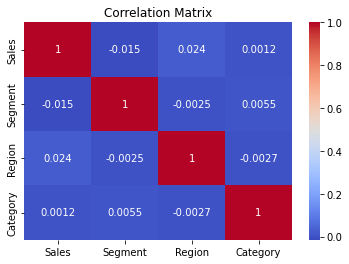

Explained Variance Ratio: [0.25744571 0.25064958]


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

The correlation matrix shows the relationships between numerical features. 
Some correlations are present, so PCA can be applied to reduce dimensionality 
while keeping the important information.

# Apply PCA

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_zscore[numerical_features])

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,1.743812,-1.403216
1,0.078775,0.474652
2,0.143145,-0.387657
3,0.988950,-1.484020
4,0.567671,-0.174167


In [45]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.25744571 0.25064958]


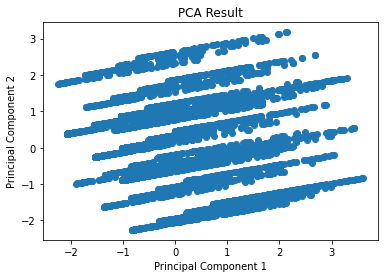

In [46]:
plt.figure(figsize=(6,4))
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.title("PCA Result")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

The correlation matrix showed very weak relationships between the selected features (Sales, Segment, Region, and Category). PCA was still applied to transform the data into two principal components as required. However, because the correlation between features is low, PCA does not provide strong dimensionality reduction in this case. The explained variance ratio shows that the two components capture part of the variance, but the benefit of PCA here is limited.

## Conclusion

In this assignment, several data preprocessing steps were applied to improve the dataset quality. 
Missing values and outliers were handled, and normalization techniques were used to scale the data. 
Finally, PCA was applied to reduce dimensionality while preserving the most important information.